# Apply 1550 nm laser
work around 1556.005 to dont disturb usman
- Check variation of peak 2 and 2N against fluctuations of power
- If possible, check variation of peaks 2 and 2N against variations of training parameters
- Check variation of baseline against fluctuations of power: $\int_{\lambda_1}^{\lambda_2} d\lambda Baseline(\lambda)$


In [18]:
# Load functions
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 
from scipy.signal import find_peaks

def nearest_tenth(x):
    return math.ceil(x * 10) / 10

def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)



# physical_model and WaveshaperLayer.forward() need the same parameters for PAT
# coefficients, phases, normalization are for physical model
# startCombline and endCombline are for forward(), since the sweep is already stored

#TODO? add phase matching data if necessary
def physical_model(coefficients, phases, startCombline, endCombline, z=1, noise_rate=0.0, old_model=False):
    if noise_rate > 0:
        #noise rate is a fraction of the mean absolute value of coefficients and phases, so that the noise scales with the signal
        coefficients = coefficients + torch.randn_like(coefficients) * (noise_rate * coefficients.abs().mean())
        phases = phases + torch.randn_like(phases) * (noise_rate * phases.abs().mean())
    
    
    N = coefficients.size(0)
  
    # convert intensities to amplitudes
    coefficients = torch.sqrt(coefficients)
    intensity = torch.zeros((2 * N - 1), dtype=torch.float, device=coefficients.device)
    for gamma in range(1, 2 * N): #2n-1 outputs
        alpha = torch.arange(max(1, gamma-N+1), min(N, gamma) + 1, 1, device=coefficients.device)
        
        # we do a lot of redundant calculation. I briefly tried cutting the summation in half but it gives weird results
        # alpha = torch.arange(max(1, gamma-N+1), (gamma + 1) // 2 + 1, 1, device=coefficients.device)

        
        terms = coefficients[alpha - 1] * coefficients[gamma - alpha] * torch.exp(1j * (phases[alpha - 1] + phases[gamma - alpha]))

        intensity[gamma - 1] = terms.sum().abs() ** 2
    
    # we need to scale the resultant intensities relative to the max if all comblines are 100% and in phase,
    # to get the same scale of values as measurement, i.e. [0, 1]
    intensity = intensity / N ** 2




    if noise_rate > 0:
        noise = torch.randn_like(intensity) * (noise_rate * intensity.abs().mean())
        #print(f"Adding intensity noise {noise}")
        intensity = torch.abs(intensity + noise)

    return intensity

import os

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")
    boundaries_path = os.path.join(base_path, "boundaries")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)
    os.makedirs(boundaries_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}\n- {boundaries_path}")


In [21]:
osa.close_connection()

Connection closed


In [88]:
SPEED_OF_LIGHT = 299792458/1
n_comblines = 50
comblines_range_A = np.arange(0, 16)
comblines_range_B = np.arange(34, 50)


# separation_comblines = 0.2
combline_freq_separation = 25 #GHZ
initial_wl = 1551.972
# initial_wl = 1543.795
initial_freq = SPEED_OF_LIGHT/initial_wl
freqs = np.arange(initial_freq, initial_freq - n_comblines * combline_freq_separation, -combline_freq_separation)

# comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
comblines = SPEED_OF_LIGHT/freqs
#get array of expected SHG wavelengths
target_freqs = np.sort(np.unique(np.add.outer(freqs, freqs)))[::-1]
targets = SPEED_OF_LIGHT/target_freqs * 1e-9# + 0.014e-9
print(f"combline wavelenths: {comblines}")
print(f"SHG wavelengths: {targets}")

combline wavelenths: [1551.972      1552.17288304 1552.3738181  1552.57480518 1552.77584432
 1552.97693552 1553.17807882 1553.37927423 1553.58052177 1553.78182146
 1553.98317332 1554.18457738 1554.38603365 1554.58754215 1554.7891029
 1554.99071593 1555.19238125 1555.39409889 1555.59586886 1555.79769119
 1555.99956589 1556.20149299 1556.40347251 1556.60550446 1556.80758887
 1557.00972575 1557.21191514 1557.41415704 1557.61645148 1557.81879848
 1558.02119806 1558.22365024 1558.42615505 1558.62871249 1558.83132259
 1559.03398538 1559.23670087 1559.43946909 1559.64229004 1559.84516377
 1560.04809028 1560.25106959 1560.45410173 1560.65718672 1560.86032457
 1561.06351532 1561.26675897 1561.47005555 1561.67340509 1561.87680759]
SHG wavelengths: [7.75986000e-07 7.76036218e-07 7.76086442e-07 7.76136672e-07
 7.76186909e-07 7.76237153e-07 7.76287403e-07 7.76337659e-07
 7.76387922e-07 7.76438192e-07 7.76488468e-07 7.76538750e-07
 7.76589039e-07 7.76639335e-07 7.76689637e-07 7.76739946e-07
 7.76790

# Intensity Calibration

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Applying profile...   success
Sweep complete.


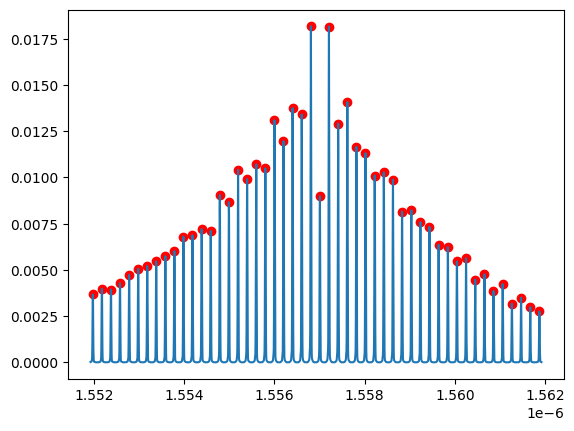

Applying profile...   success
Sweep complete.


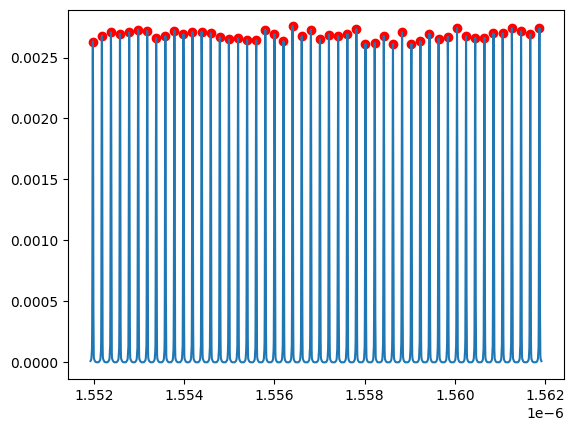

Applying profile...   success
Sweep complete.


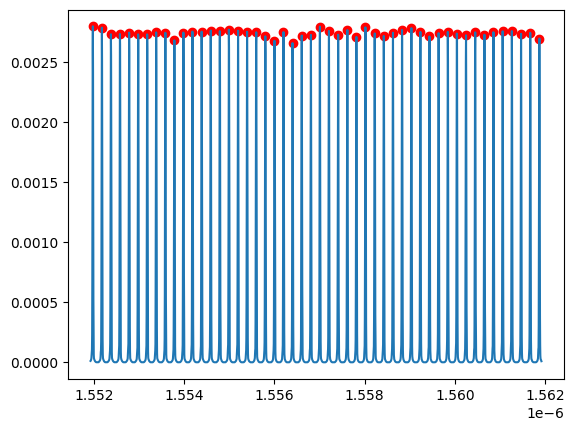

Relative combline intensities: [1.28154423 1.41336478 1.41158332 1.52820328 1.69865989 1.83167397
 1.87994368 1.9260896  2.03613152 2.17323589 2.42707474 2.47120116
 2.59031773 2.54527375 3.20035409 3.04467283 3.67082982 3.47895809
 3.75340886 3.79939566 4.68112021 4.18065677 5.02709168 4.7557924
 6.58023541 3.15874062 6.48045517 4.57984177 5.03134637 4.22627692
 3.92416412 3.51174324 3.64649324 3.42223604 2.92923614 2.85181766
 2.64642317 2.61889873 2.24082159 2.20578272 1.98540817 1.99547272
 1.57914144 1.6790366  1.3817524  1.51418953 1.15070572 1.25798079
 1.06457402 1.        ]


In [36]:
# Connect OSA directly to waveshaper output (NOT SHG)
# Measures relative combline powers, so we can adjust peaks to get them even
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
peaks = np.ones(n_comblines)*1
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
relative_combline_intensities = np.ones(n_comblines)
N_revisions=2
for i in range(N_revisions+1):
    apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases, channels, plot = False, delta_l=0.05, sigma=0.005)
    wavelengths, power = osa.perform_measurement_OSA((np.max(comblines)+np.min(comblines))/2, nearest_tenth((np.max(comblines)-np.min(comblines))*1.0), 5000, sensitivity = "high1", resolution = 0.02)
    combline_indices = [np.argmin(np.abs(wavelengths - combline*1e-9)) for combline in comblines]
    radius = (combline_indices[1] - combline_indices[0])//2

    combline_intensities = np.array([
        np.array(power)[max(0, i-radius):min(len(power), i+radius)-1].max()
        for i in combline_indices
    ])

    plt.plot(wavelengths, power)
    plt.scatter(np.array(wavelengths)[combline_indices], combline_intensities, color="red")
    plt.show()

    if i < N_revisions:
        relative_combline_intensities *= combline_intensities
        relative_combline_intensities /= np.min(relative_combline_intensities)

print(f"Relative combline intensities: {relative_combline_intensities}")

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


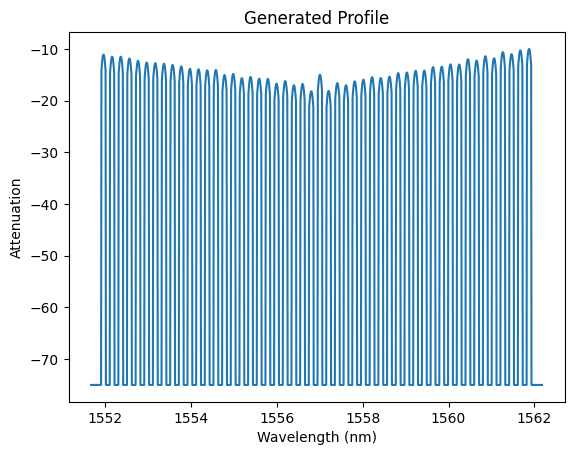

Applying profile...   success
Sweep complete.


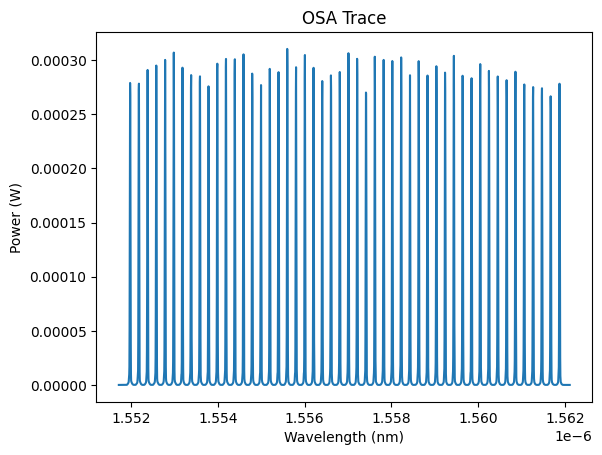

In [38]:
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
apply_waveshaper_profile(comblines, np.ones(50)*.1 / relative_combline_intensities, phases, channels, plot = True, delta_l=0.05, sigma=0.005)
wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines), (np.max(comblines)-np.min(comblines))*1.05, 20, sensitivity = "high1", resolution = 0.02)
osa.plot_trace(wavelengths, power)

# Phase and Normalization

In [84]:
# Phase Alignment Calibration


# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()


channels = np.ones(n_comblines)
phase_offsets = np.zeros(n_comblines)

def find_phase_offset(test_combline, static_comblines, spike_wavelength, detail, center_phase=0, range=2*np.pi):
    peaks = np.zeros(n_comblines)
    peaks[test_combline] = 1
    peaks[static_comblines] = 1
    spike_index = None
    

    #looking for destructive rather than constructive terms gives greater accuracy
    lowest_intensity = np.inf
    worst_phase = 0

    for phase in np.linspace(center_phase - range/2, center_phase + range/2, detail, endpoint=(range<2*np.pi)):
        phase_offsets[test_combline] = phase
        apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phase_offsets, channels, plot = False, delta_l=0.05, sigma=0.005)
        wavelengths, power = osa.perform_measurement_OSA(spike_wavelength*1e9, 0.2, 2, sensitivity = "high2", resolution = 0.02)

        if spike_index == None: 
            spike_index = np.argmin(np.abs(wavelengths - spike_wavelength))
        spike_intensity = power[spike_index]
        print(f"Phase {phase:.2f} rad: Spike intensity = {spike_intensity}")

        if spike_intensity < lowest_intensity:
            lowest_intensity = spike_intensity
            worst_phase = phase


    if range < 2*np.pi:
        phase_offsets[test_combline] = worst_phase + np.pi
    else:
        print(f"---Searching around {worst_phase:.2f} rad---")
        find_phase_offset(test_combline, static_comblines, spike_wavelength, detail, center_phase=worst_phase, range=range/detail)


#start inclusive, end exclusive
from itertools import product
def find_phases_for_range(start, end, res, mode=2):
    
# Here we have two methods for calibrating a range of comblines. The first one ensures adjacent comblines are well-calibrated,
# but global consistency suffers as errors add up across bigger ranges. The second gives slightly better performance if stronger intraband
# SHG is needed, but phases between adjacent comblines are less consistent. 

    if mode == 1:



        for i in range(start + 2, end):
                find_phase_offset(i, [start, start+1, i-1], targets[start+i], (10 if res=="high" else 5))
                print(f"-----Best phase for combline {i} is {phase_offsets[i]}-----     {(i - start - 1) / (end - start - 2) * 100:.1f}%")



    else:


        calibrated = np.array([start, start + 1])
        steps = 0
        while calibrated.size < end - start:
            # Here we do a sort of breadth first search, using the currently calibrated comblines to calibrate all other possible
            # comblines (including non-adjacent ones) with a single step. This ensures the fewest number of steps, and thus least accumulated error, to calibrate all comblines
            steps += 1
            for reference_1, reference_2, reference_3 in product(calibrated, repeat=3):

                tester = reference_1 + reference_2 - reference_3 
                if tester not in calibrated and tester >= start and tester < end:
                    print(f"Finding {tester} with references {reference_1}, {reference_2}, {reference_3}; {steps} step(s)")
                    # target_idx = min(tester, reference_1, reference_2, reference_3) + max(tester, reference_1, reference_2, reference_3)
                    target_idx = reference_1 + reference_2
                    find_phase_offset(tester, [reference_1, reference_2, reference_3], targets[target_idx], (10 if res=="high" else 5))
                    calibrated = np.append(calibrated, tester)
                    print(f"-----Best phase for combline {tester} is {phase_offsets[tester]}-----     {(calibrated.size - 2) / (end - start - 2) * 100:.1f}%")



find_phases_for_range(comblines_range_A[0], comblines_range_A[-1]+1, res="low")
find_phases_for_range(comblines_range_B[0], comblines_range_B[-1]+1, res="low")

phase_offsets = (phase_offsets - phase_offsets[0] + np.pi) % (2 * np.pi) - np.pi
print(f"Phase offsets: {phase_offsets}")


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Finding 2 with references 1, 1, 0; 1 step(s)
Applying profile...   success
Sweep complete.
Phase -3.14 rad: Spike intensity = 2.80713724e-05
Applying profile...   success
Sweep complete.
Phase -1.88 rad: Spike intensity = 8.18151551e-05
Applying profile...   success
Sweep complete.
Phase -0.63 rad: Spike intensity = 0.000166342684
Applying profile...   success
Sweep complete.
Phase 0.63 rad: Spike intensity = 0.000189120587
Applying profile...   success
Sweep complete.
Phase 1.88 rad: Spike intensity = 9.90198849e-05
---Searching around -3.14 rad---
Applying profile...   success
Sweep complete.
Phase -3.77 rad: Spike intensity = 5.86130249e-05
Applying profile...   success
Sweep complete.
Phase -3.46 rad: Spike intensity = 4.29253038e-05
Applying profile...   success
Sweep complete.
Phase -3.14 rad: Spike intensity 

(-3.141592653589793, 3.141592653589793)

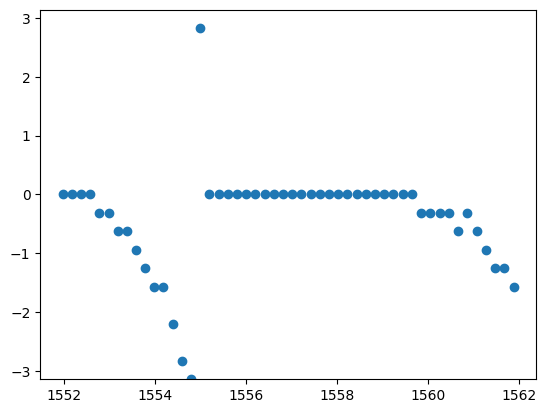

In [85]:
# change backend of pyplot to a latex based backend
# Set properly the labels and legends of the graphs and save in a vectorized pdf
# paste in overleaf for report, see how to include insets
plt.scatter(comblines, phase_offsets)
plt.ylim(-np.pi, np.pi)

In [57]:
phase_offsets = np.zeros(n_comblines)

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


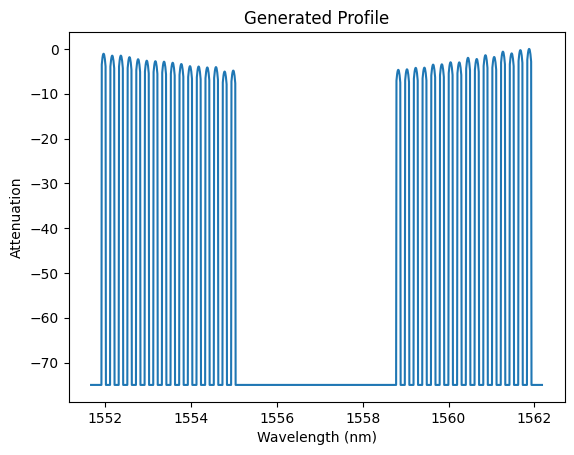

Applying profile...   success
Sweep complete.
A Indices [np.int64(28), np.int64(43), np.int64(57), np.int64(72), np.int64(87), np.int64(102), np.int64(117), np.int64(131), np.int64(146), np.int64(161), np.int64(176), np.int64(191), np.int64(205), np.int64(220), np.int64(235), np.int64(250), np.int64(264), np.int64(279), np.int64(294), np.int64(309), np.int64(324), np.int64(339), np.int64(353), np.int64(368), np.int64(383), np.int64(398), np.int64(413), np.int64(427), np.int64(442), np.int64(457), np.int64(472)]


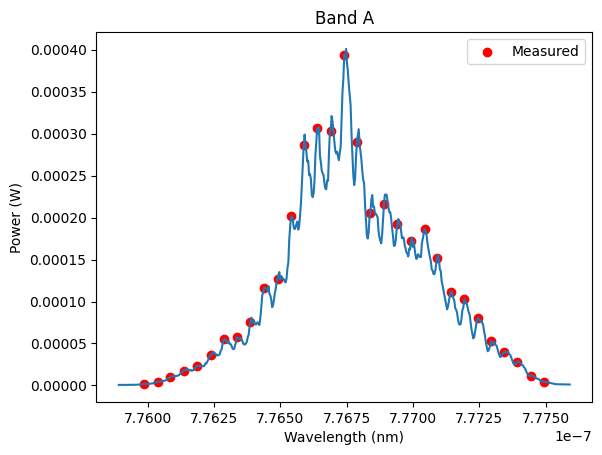

Sweep complete.
B Indices [np.int64(28), np.int64(43), np.int64(57), np.int64(72), np.int64(87), np.int64(102), np.int64(117), np.int64(131), np.int64(146), np.int64(161), np.int64(176), np.int64(191), np.int64(205), np.int64(220), np.int64(235), np.int64(250), np.int64(264), np.int64(279), np.int64(294), np.int64(309), np.int64(324), np.int64(339), np.int64(353), np.int64(368), np.int64(383), np.int64(398), np.int64(413), np.int64(427), np.int64(442), np.int64(457), np.int64(472)]


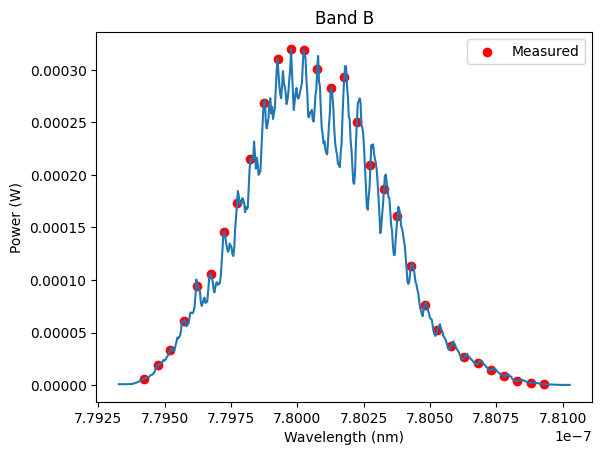

In [89]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour


# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()


# print(comblines / 2)
peaks = np.zeros(n_comblines)*1
# peaks = np.array([1, 1, 1, 0, 0, 0, 0, 1, 1, 1])
peaks[comblines_range_A] = 1
peaks[comblines_range_B] = 1

phases = np.zeros(n_comblines)
# phases = np.linspace(0, np.pi, n_comblines)
channels = np.ones(n_comblines)

# apply_waveshaper_profile(comblines, phases, phases, channels, plot = False)
apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases + phase_offsets, channels, plot = True, delta_l=0.05, sigma=0.005)



targets_A = targets[2*comblines_range_A[0]:2*comblines_range_A[-1]+1]
targets_B = targets[2*comblines_range_B[0]:2*comblines_range_B[-1]+1]
wavelengths, power = osa.perform_measurement_OSA((np.max(targets_A)+np.min(targets_A))/2*1e9, (np.max(targets_A)-np.min(targets_A))*1.1e9, 0.1, sensitivity = "high2", resolution = 0.02)
normalizationA = np.max(power)
shg_indices_A = [np.argmin(np.abs(wavelengths - t)) for t in targets_A]
print(f"A Indices {shg_indices_A}")


plt.plot(wavelengths, power)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (W)')
plt.title('Band A')
plt.scatter(np.array(wavelengths)[shg_indices_A], np.array(power)[shg_indices_A], color='red', label='Measured')
plt.legend()
plt.show()


wavelengths, power = osa.perform_measurement_OSA((np.max(targets_B)+np.min(targets_B))/2*1e9, (np.max(targets_B)-np.min(targets_B))*1.1e9, 0.1, sensitivity = "high2", resolution = 0.02)
normalizationB = np.max(power)
shg_indices_B = [np.argmin(np.abs(wavelengths - t)) for t in targets_B]
print(f"B Indices {shg_indices_A}")


plt.plot(wavelengths, power)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (W)')
plt.title('Band B')
plt.scatter(np.array(wavelengths)[shg_indices_A], np.array(power)[shg_indices_A], color='red', label='Measured')
plt.legend()
plt.show()

# sim = physical_model(torch.tensor(peaks), torch.tensor(phases), 0, 0).squeeze()
# plt.scatter(targets, sim / torch.max(sim) * np.max(power), color='black', label='Simulated')
# plt.yscale('linear')





# initrang = 122
# finrang = 498
# #for each target wavelength, find the index of the closest wavelength in the OSA measurement
# wavelength_trim = wavelengths[initrang:finrang]




In [56]:
targets[n_comblines-1]

np.float64(7.774087094278356e-07)

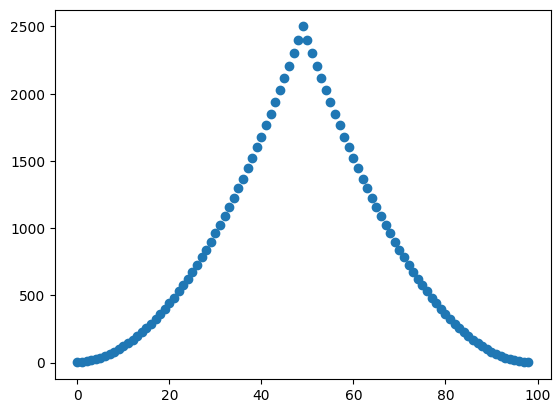

In [11]:
peaks = np.ones(n_comblines)
phases = np.zeros(n_comblines)


plt.scatter(np.arange(n_comblines*2-1), physical_model(torch.tensor(peaks), torch.tensor(phases), 0, 0).squeeze(), label='Model Prediction')

# Fitting [Deprecated]

Sweep complete.
the power is 1476


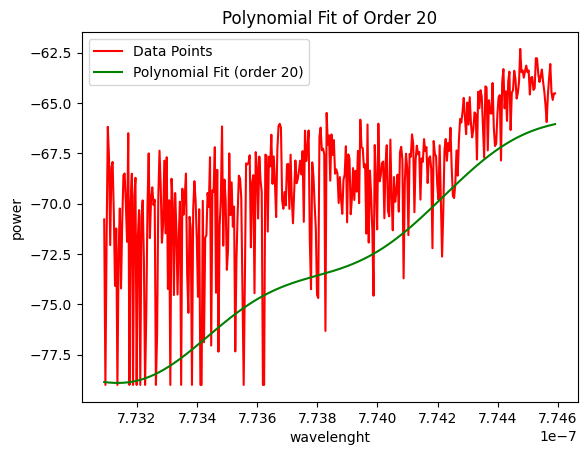

The len prominence is 376
number of maximum points 53
1.0


Text(0, 0.5, 'Amplitude')

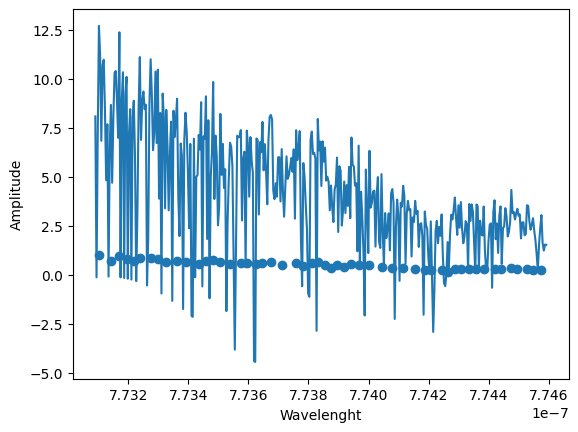

In [ ]:
# Perform calibration
order = 20
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='log', sensitivity="high1")
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 498
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
print(f'The len prominence is {len(wavelength_trim)}')
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=20e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
normalization = 1/(fraction_max_min*max_y[0])
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')


Sweep complete.
the power is 1476


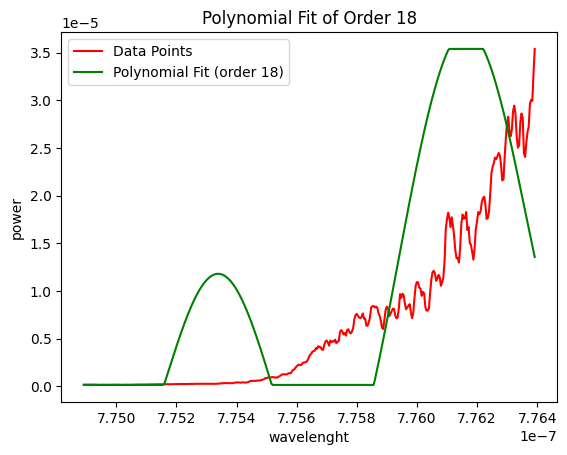

number of maximum points 20
1.8939444507976126


Text(0, 0.5, 'Amplitude')

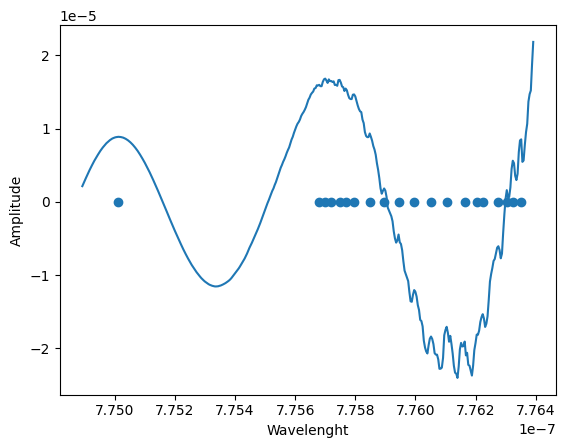

In [ ]:
# Perform calibration
order = 18
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='lin')
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 498
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=1e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
#normalization = 1/(fraction_max_min*max_y[0])
normalization = np.max(power)
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')

# Training

In [90]:
# Load datasets
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import imageio  # Import the imageio library

# ===== MODEL A: make_moons dataset =====
# Step 1: Generate the make_moons dataset
X_A, y_A = make_moons(n_samples=70, noise=0.15, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min_A = np.min(X_A, axis=0)
X_max_A = np.max(X_A, axis=0)
X_scaled_0_1_A = (X_A - X_min_A) / (X_max_A - X_min_A)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1_A = 2 * X_scaled_0_1_A - 1

# Step 4: Split the dataset into training and testing sets
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_scaled_neg1_1_A, y_A, test_size=0.5, random_state=42)

# Step 5: Convert the data to PyTorch tensors
X_train_A = torch.tensor(X_train_A, dtype=torch.float32)
X_test_A = torch.tensor(X_test_A, dtype=torch.float32)
y_train_A = torch.tensor(y_train_A, dtype=torch.float32)
y_test_A = torch.tensor(y_test_A, dtype=torch.float32)

# ===== MODEL B: make_circles dataset =====
# Step 1: Generate the make_circles dataset
X_B, y_B = make_circles(n_samples=70, factor=0.5, noise=0.1, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min_B = np.min(X_B, axis=0)
X_max_B = np.max(X_B, axis=0)
X_scaled_0_1_B = (X_B - X_min_B) / (X_max_B - X_min_B)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1_B = 2 * X_scaled_0_1_B - 1

# Step 4: Split the dataset into training and testing sets
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_scaled_neg1_1_B, y_B, test_size=0.5, random_state=42)

# Step 5: Convert the data to PyTorch tensors
X_train_B = torch.tensor(X_train_B, dtype=torch.float32)
X_test_B = torch.tensor(X_test_B, dtype=torch.float32)
y_train_B = torch.tensor(y_train_B, dtype=torch.float32)
y_test_B = torch.tensor(y_test_B, dtype=torch.float32)


In [91]:
# Waveshaper layer

class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        #self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma

        self.intensities = torch.zeros((2 * n_comblines + 1), dtype=torch.float)
        
        # Convert comblines to THz
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        

        self.shg_indices_A = None
        self.shg_indices_B = None


        # Trainable phases
        # self.phases = nn.Parameter(torch.zeros(n_comblines))
        
    def performOSASweep(self, peaks, phi, normalizationA, normalizationB):
        # Generate signal profile for each combline
        max_y = np.zeros(2*n_comblines-1)
        apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)

        wavelengths, power = osa.perform_measurement_OSA((np.max(targets_A)+np.min(targets_A))/2*1e9, (np.max(targets_A)-np.min(targets_A))*1.1e9, normalizationA*1e3, sensitivity = "high2", resolution = 0.02)
        max_y[comblines_range_A[0]*2:comblines_range_A[-1]*2+1] = np.array(power)[shg_indices_A] / normalizationA

        wavelengths, power = osa.perform_measurement_OSA((np.max(targets_B)+np.min(targets_B))/2*1e9, (np.max(targets_B)-np.min(targets_B))*1.1e9, normalizationB*1e3, sensitivity = "high2", resolution = 0.02)
        max_y[comblines_range_B[0]*2:comblines_range_B[-1]*2+1] = np.array(power)[shg_indices_B] / normalizationB


        # Convert max_y (NumPy array) back to a tensor
        self.intensities = (torch.tensor(max_y, dtype=torch.float32))
        #print(f"The output from OSA is {torch.unsqueeze(max_y_tensor,0)}")
        # self.intensities = torch.unsqueeze(max_y_tensor,0)



    # physical_model and WaveshaperLayer.forward() need the same parameters for PAT
    # coefficients, phases, normalization are for physical model
    # startCombline and endCombline are for forward(), since the sweep is already stored

    def forward(self, peaks, phi, startCombline, endCombline):    
        # Return sliced tensor of intensities, from 2*startCombline to 2*endCombline inclusive
        # return self.intensities[:, 2*startCombline:2*endCombline+1]
        return self.intensities[2*startCombline:2*endCombline+1]
    

In [92]:
from pat import make_pat_func
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

# Create a Model
# comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
channels = np.ones(n_comblines)

# Create the layer and pass input peaks
layer = WaveshaperLayer(osa, comblines=comblines, channels=channels)

#this code is used to construct the PAT functions
#pat_implementation = make_pat_func(physical_model, physical_model)




class Dual_Physical_NN_SHG(nn.Module):
    #TODO this is a lot of ugly repeated code, because we have all the parameters and steps for both
    #       models packed together in a joint model (intermediate layer data from both models is needed for OSA, which is ugly or impossible to sync between discrete models)
    #       In the future when we want to do this for >2 models, it's probably best to do all this with arrays or tensors or something we can iterate through for properly generic code
    #       Or, if we're training one model but running multiple batches simultaneously, we can just have one set of parameters
    def __init__(self, AstartCombline, AendCombline, BstartCombline, BendCombline, noise_rate=0.0):
        super(Dual_Physical_NN_SHG, self).__init__()
        A_hidden_dim = AendCombline - AstartCombline + 1
        self.Aalpha = nn.Parameter(torch.zeros(2 * A_hidden_dim - 1))
        self.Abias = nn.Parameter(torch.zeros(1))
        self.Aphases = nn.Parameter(torch.randn(A_hidden_dim))
        self.Afc = nn.Linear(X_train_A.size(1), A_hidden_dim)
        self.Aln = nn.LayerNorm(2 * A_hidden_dim - 1)
        # 0 indexed, inclusive on both ends
        self.AstartCombline = AstartCombline
        self.AendCombline = AendCombline

        B_hidden_dim = BendCombline - BstartCombline + 1
        self.Balpha = nn.Parameter(torch.zeros(2 * B_hidden_dim - 1))
        self.Bbias = nn.Parameter(torch.zeros(1))
        self.Bphases = nn.Parameter(torch.randn(B_hidden_dim))
        self.Bfc = nn.Linear(X_train_B.size(1), B_hidden_dim)
        self.Bln = nn.LayerNorm(2 * B_hidden_dim - 1)
        # 0 indexed, inclusive on both ends
        self.BstartCombline = BstartCombline
        self.BendCombline = BendCombline

        # Initialize fc_logvar: weights around 0 and bias to a negative value (e.g. -1.0).

        nn.init.normal_(self.Afc.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.Afc.bias, 0)
        nn.init.normal_(self.Bfc.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.Bfc.bias, 0)

        # We need to wrap the functions that pat uses because it expects differentiable float parameters,
        # and doesn't play well with the combline indices. Could be solved by changing pat.py but i dont wanna mess with that
        def physical_model_wrapper_A(amplitudes, phases):
            return physical_model(amplitudes, phases, self.AstartCombline, self.AendCombline, noise_rate=noise_rate)
        def physical_model_wrapper_B(amplitudes, phases):
            return physical_model(amplitudes, phases, self.BstartCombline, self.BendCombline, noise_rate=noise_rate)
        def waveshaper_wrapper_A(amplitudes, phases):
            return layer.forward(amplitudes, phases, self.AstartCombline, self.AendCombline)
        def waveshaper_wrapper_B(amplitudes, phases):
            return layer.forward(amplitudes, phases, self.BstartCombline, self.BendCombline)
        

        self.pat_layer_A = make_pat_func(waveshaper_wrapper_A, physical_model_wrapper_A)
        self.pat_layer_B = make_pat_func(waveshaper_wrapper_B, physical_model_wrapper_B)

    
    def forward(self, xA, xB, normalizationA, normalizationB):
        # Expect x to be a 2-element tensor: [x0, x1]
        # x0, x1 = x[0], x[1]

        # x0_val = x0 if x0 > 0 else -x0
        # phi0   = 0.0 if x0 > 0 else np.pi * x0

        # x1_val = x1 if x1 > 0 else -x1
        # phi1 = 0.0 if x1 > 0 else np.pi * x1

        # ones = torch.ones(1, dtype=x.dtype, device=x.device)
        # x_cat = torch.cat((
        #     ones,
        #     torch.tensor([x0_val.item()] * 5, dtype=x.dtype, device=x.device),
        #     ones.repeat(3),
        #     torch.tensor([x1_val.item()] * 5, dtype=x.dtype, device=x.device),
        #     ones
        # ), dim=0)

        # phi = torch.tensor(
        #     [0.0] + [phi0] * 5 + [0.0] * 3 + [phi1] * 5 + [0.0],
        #     dtype=x.dtype, device=x.device
        # )+self.phases


        # Apply the custom PAT layer.

        xA = self.Afc(xA)
        xB = self.Bfc(xB)
        #x = self.ln1(x)
        #print(f"The input of pat {xA}, {xB}")
        Aphase = torch.where(xA < 0, torch.tensor(np.pi, device=xA.device), torch.tensor(0.0, device=xA.device))
        xA = torch.abs(xA)
        xA = xA / torch.max(xA).clamp(min=1e-5)
        Bphase = torch.where(xB < 0, torch.tensor(np.pi, device=xB.device), torch.tensor(0.0, device=xB.device))
        xB = torch.abs(xB)
        xB = xB / torch.max(xB).clamp(min=1e-5)
        if not isinstance(normalizationA, torch.Tensor):
            normalizationA = torch.tensor(normalizationA, dtype=torch.float32, device=X_train_A.device)
        if not isinstance(normalizationB, torch.Tensor):
            normalizationB = torch.tensor(normalizationB, dtype=torch.float32, device=X_train_B.device) 
        # Construct full amplitude array for entire frequency space
        full_peaks = torch.zeros(n_comblines, dtype=xA.dtype, device=xA.device)
        full_peaks[self.AstartCombline:self.AendCombline+1] = xA
        full_peaks[self.BstartCombline:self.BendCombline+1] = xB
        
        # Construct full phases array for entire frequency space
        full_phases = torch.zeros(n_comblines, dtype=xA.dtype, device=xA.device)
        full_phases[self.AstartCombline:self.AendCombline+1] = self.Aphases*xA + Aphase
        full_phases[self.BstartCombline:self.BendCombline+1] = self.Bphases*xB + Bphase
        
        #perform SHG and OSA measurement. Results are stored internally in waveshaper layer
        #TODO speedup by jumping over the gap
        layer.performOSASweep(full_peaks, full_phases, normalizationA, normalizationB)
        #perform PAT for both models. Forward it just retrieves the relevant slice of the OSA measurement
        
        outA = self.pat_layer_A(xA, self.Aphases*xA+Aphase)
        outB = self.pat_layer_B(xB, self.Bphases*xB+Bphase)
        print(f"The output from the pat is {outA}, {outB}, norm {normalizationA}, {normalizationB}")

        outA = self.Aln(outA) 
        outB = self.Bln(outB)
        # Final linear transformation.
        #TODO why is this not just a linear layer?
        outA = torch.matmul(outA, self.Aalpha) + self.Abias
        outB = torch.matmul(outB, self.Balpha) + self.Bbias
        return outA, outB

    def parameters_A(self):

        return [self.Aalpha, self.Abias, self.Aphases] + list(self.Afc.parameters()) + list(self.Aln.parameters())



    def parameters_B(self):        return [self.Balpha, self.Bbias, self.Bphases] + list(self.Bfc.parameters()) + list(self.Bln.parameters())

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


In [74]:
print(normalizationA, normalizationB)

0.00119583457 0.000895674196


Folders ensured:
- data_runs\experiment_dual_09\stability
- data_runs\experiment_dual_09\checkpoints
- data_runs\experiment_dual_09\traces
- data_runs\experiment_dual_09\boundaries


C:\Users\jacka\AppData\Local\Temp\ipykernel_39296\3108410702.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0084, 0.0102, 0.0321, 0.0087, 0.0245, 0.0560, 0.0550, 0.0060, 0.0582,
        0.0325, 0.0831, 0.0230, 0.0732, 0.0969, 0.0469, 0.0623, 0.2535, 0.1511,
        0.0591, 0.0167, 0.0579, 0.0440, 0.1097, 0.0808, 0.1302, 0.0122, 0.0290,
        0.0068, 0.0059, 0.0342, 0.0129], grad_fn=<funcBackward>), tensor([7.8034e-03, 4.3476e-02, 8.1629e-02, 1.7851e-01, 1.2643e-01, 1.8861e-01,
        1.6793e-01, 1.9920e-01, 2.5758e-01, 5.0256e-01, 9.7490e-01, 3.9502e-01,
        2.8160e-01, 2.6716e-01, 2.6906e-01, 1.3175e-01, 2.7166e-01, 1.5447e-01,
        2.5702e-02, 2.7066e-02, 1.0403e-02, 1.0105e-02, 1.4480e-02, 1.0996e-02,
        2.2141e-03, 1.4907e-02, 5.5902e-03, 3.5931e-03, 2.0977e-03, 8.2029e-04,
        5.9569e-04], grad_fn=<funcBackward>), norm 0.0004009782278444618, 0.0003199006023351103
The train binary A is 0.0; the output A is tensor([0.], grad_fn=<AddBackward0>)
The train binary B is 0.0; th

C:\Users\jacka\AppData\Local\Temp\ipykernel_39296\3108410702.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0105, 0.0172, 0.0559, 0.0239, 0.0467, 0.0220, 0.0522, 0.0740, 0.0453,
        0.0725, 0.0308, 0.0177, 0.1445, 0.2803, 0.0304, 0.0706, 0.1511, 0.2148,
        0.1428, 0.0463, 0.1463, 0.0181, 0.2359, 0.0489, 0.3172, 0.0231, 0.0884,
        0.2251, 0.1435, 0.1159, 0.0431], grad_fn=<funcBackward>), tensor([0.0057, 0.0265, 0.0394, 0.1266, 0.0728, 0.1791, 0.1057, 0.0972, 0.2616,
        0.2268, 0.3494, 0.1258, 0.0566, 0.0533, 0.2411, 0.0469, 0.0598, 0.0606,
        0.0063, 0.0266, 0.0091, 0.0094, 0.0103, 0.0058, 0.0009, 0.0018, 0.0059,
        0.0016, 0.0016, 0.0005, 0.0004], grad_fn=<funcBackward>), norm 0.00019475887529551983, 0.000597326667048037
The train binary A is 0.0; the output A is tensor([-2.3894], grad_fn=<AddBackward0>)
The train binary B is 0.0; the output B is tensor([-1.2671], grad_fn=<AddBackward0>)
Applying profile...   success
Sweep complete.
Sweep complete.
The output from t

...

Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0101, 0.0174, 0.0464, 0.0606, 0.0411, 0.0468, 0.0745, 0.0382, 0.0741,
        0.0251, 0.0300, 0.1268, 0.0555, 0.4647, 0.2404, 0.1178, 0.2134, 0.1372,
        0.0808, 0.1954, 0.3837, 0.1265, 0.0619, 0.1546, 0.2895, 0.0725, 0.2357,
        0.2397, 0.1282, 0.0637, 0.0250], grad_fn=<funcBackward>), tensor([0.0117, 0.0299, 0.0523, 0.0778, 0.0370, 0.0721, 0.1276, 0.0770, 0.0073,
        0.0245, 0.0731, 0.1123, 0.0653, 0.0339, 0.1146, 0.1065, 0.0076, 0.0348,
        0.0329, 0.0069, 0.0283, 0.0216, 0.0265, 0.0152, 0.0053, 0.0054, 0.0119,
        0.0116, 0.0024, 0.0019, 0.0006], grad_fn=<funcBackward>), norm 0.000233680140809156, 0.0007104767137207091
The train binary A is 0.0; the output A is tensor([-7.1867], grad_fn=<AddBackward0>)
The train binary B is 0.0; the output B is tensor([-7.0260], grad_fn=<AddBackward0>)
Applying profile...   success
Sweep complete.
Sweep complete.
The output from th

C:\Users\jacka\AppData\Local\Temp\ipykernel_39296\3108410702.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0115, 0.0214, 0.0527, 0.0555, 0.0371, 0.0477, 0.0691, 0.0422, 0.0777,
        0.0263, 0.0278, 0.1190, 0.0521, 0.4415, 0.2321, 0.1187, 0.2088, 0.1440,
        0.0836, 0.1962, 0.4036, 0.1271, 0.0648, 0.1555, 0.2936, 0.0730, 0.2398,
        0.2460, 0.1278, 0.0664, 0.0257], grad_fn=<funcBackward>), tensor([0.0103, 0.0270, 0.0477, 0.0763, 0.0339, 0.0727, 0.1370, 0.0934, 0.0089,
        0.0242, 0.0672, 0.1102, 0.0595, 0.0304, 0.1077, 0.1035, 0.0077, 0.0339,
        0.0279, 0.0064, 0.0267, 0.0184, 0.0236, 0.0136, 0.0050, 0.0045, 0.0112,
        0.0154, 0.0016, 0.0014, 0.0005], grad_fn=<funcBackward>), norm 0.00021864523296244442, 0.0007554063922725618
The train binary A is 0.0; the output A is tensor([-7.4140], grad_fn=<AddBackward0>)
The train binary B is 0.0; the output B is tensor([-7.3492], grad_fn=<AddBackward0>)
Applying profile...   success
Sweep complete.
Sweep complete.
The output from 

C:\Users\jacka\AppData\Local\Temp\ipykernel_39296\3108410702.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0095, 0.0179, 0.0474, 0.0561, 0.0413, 0.0480, 0.0638, 0.0354, 0.0773,
        0.0254, 0.0285, 0.1018, 0.0462, 0.4443, 0.2275, 0.1130, 0.1986, 0.1369,
        0.0840, 0.2013, 0.3791, 0.1248, 0.0592, 0.1490, 0.2789, 0.0719, 0.2456,
        0.2402, 0.1289, 0.0628, 0.0282], grad_fn=<funcBackward>), tensor([0.0105, 0.0301, 0.0581, 0.1221, 0.0513, 0.0695, 0.1265, 0.0892, 0.0082,
        0.0225, 0.0622, 0.1105, 0.0698, 0.0248, 0.1064, 0.1078, 0.0097, 0.0378,
        0.0223, 0.0056, 0.0282, 0.0211, 0.0215, 0.0151, 0.0043, 0.0064, 0.0135,
        0.0162, 0.0021, 0.0021, 0.0006], grad_fn=<funcBackward>), norm 0.00024939473951235414, 0.0007688735495321453
The train binary A is 0.0; the output A is tensor([-7.4165], grad_fn=<AddBackward0>)
The train binary B is 0.0; the output B is tensor([-6.5557], grad_fn=<AddBackward0>)
Applying profile...   success
Sweep complete.
Sweep complete.
The output from 

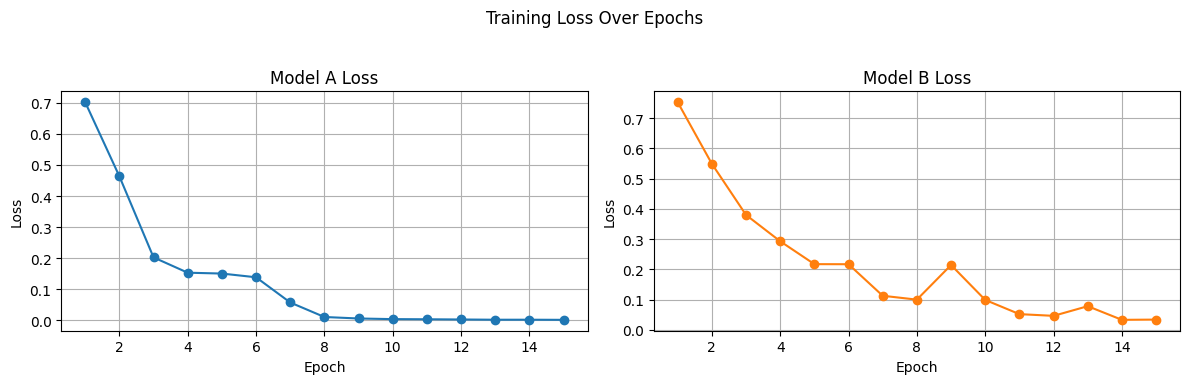

C:\Users\jacka\AppData\Local\Temp\ipykernel_39296\3108410702.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0343, 0.0147, 0.0406, 0.0553, 0.0150, 0.0277, 0.2999, 0.0507, 0.0911,
        0.2990, 0.0382, 0.0604, 0.0403, 0.0539, 0.3708, 0.0712, 0.1774, 0.2613,
        0.0562, 0.0545, 0.0323, 0.3516, 0.0801, 0.0247, 0.0274, 0.0870, 0.0200,
        0.0902, 0.1266, 0.1120, 0.0463]), tensor([0.0206, 0.0707, 0.1095, 0.1222, 0.0502, 0.1055, 0.2554, 0.1196, 0.0152,
        0.0393, 0.0722, 0.0795, 0.0172, 0.0284, 0.1146, 0.0707, 0.0228, 0.0487,
        0.0510, 0.0089, 0.0335, 0.0152, 0.0082, 0.0070, 0.0148, 0.0033, 0.0148,
        0.0218, 0.0069, 0.0027, 0.0012]), norm 0.00021042591833975166, 0.0007385481731034815
Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0263, 0.0084, 0.0253, 0.0562, 0.0154, 0.0238, 0.2225, 0.0555, 0.0672,
        0.2368, 0.0287, 0.0549, 0.0262, 0.0293, 0.3453, 0.0812, 0.1943, 0.2550,
        0.0546, 0.0413, 0.0268, 0.4051, 0.0869,

In [93]:
name_of_experiment = "experiment_dual_09"  # Replace with your desired folder name
create_folders(name_of_experiment)
epochs = 15
test_frequency = 1
# Convert y_train_A and y_train_B to have values 0 and 1 for binary classification
import json
import time
y_train_binary_A = (y_train_A > 0).float()
y_test_binary_A = (y_test_A > 0).float()
y_train_binary_B = (y_train_B > 0).float()
y_test_binary_B = (y_test_B > 0).float()

def save_meshgrid_and_data(xx, yy, Z, X, y, model_name):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        model_name (str): Name of the model.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    filename=f"./data_runs/{name_of_experiment}/meshgrid_data_{model_name}.json"

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# Example usage within your function
def plot_decision_boundary(X_A, y_A, X_B, y_B, model, epoch, nameA, nameB, save_meshgrid = False):
    # Create meshgrids for both datasets
    x_min_A, x_max_A = X_A[:, 0].min(), X_A[:, 0].max()
    y_min_A, y_max_A = X_A[:, 1].min(), X_A[:, 1].max()
    xx_A, yy_A = np.meshgrid(np.linspace(x_min_A, x_max_A, 11, endpoint=True),
                             np.linspace(y_min_A, y_max_A, 11, endpoint=True))
    
    x_min_B, x_max_B = X_B[:, 0].min(), X_B[:, 0].max()
    y_min_B, y_max_B = X_B[:, 1].min(), X_B[:, 1].max()
    xx_B, yy_B = np.meshgrid(np.linspace(x_min_B, x_max_B, 11, endpoint=True),
                             np.linspace(y_min_B, y_max_B, 11, endpoint=True))
    
    grid_A = np.c_[xx_A.ravel(), yy_A.ravel()]
    grid_A_tensor = torch.tensor(grid_A, dtype=torch.float32)
    
    grid_B = np.c_[xx_B.ravel(), yy_B.ravel()]
    grid_B_tensor = torch.tensor(grid_B, dtype=torch.float32)

    Z_A = np.empty(grid_A_tensor.shape[0])
    Z_B = np.empty(grid_B_tensor.shape[0])
    
    with torch.no_grad():
        # Evaluate both models together on their respective grids
        for point_idx in range(grid_A_tensor.shape[0]):
            out_A, out_B = model(grid_A_tensor[point_idx], grid_B_tensor[point_idx], normalizationA, normalizationB)
            z_value_A = torch.tanh(out_A)
            z_value_B = torch.tanh(out_B)
            Z_A[point_idx] = z_value_A.item()
            Z_B[point_idx] = z_value_B.item()
        
    Z_A = Z_A.reshape(xx_A.shape)
    Z_B = Z_B.reshape(xx_B.shape)

    # Save meshgrid and data points for both models
    if save_meshgrid:
        save_meshgrid_and_data(xx_A, yy_A, Z_A, X_A, y_A, nameA)
        save_meshgrid_and_data(xx_B, yy_B, Z_B, X_B, y_B, nameB)

    # Plotting with subplots - both models side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Model A (Make Moons)
    ax1.contourf(xx_A, yy_A, Z_A, alpha=0.8, cmap=plt.cm.Spectral)
    ax1.scatter(X_A[:, 0], X_A[:, 1], c=y_A, edgecolors='k', cmap=plt.cm.Spectral)
    ax1.set_title(f'{nameA} - Epoch {epoch}')
    
    # Plot Model B (Make Circles)
    ax2.contourf(xx_B, yy_B, Z_B, alpha=0.8, cmap=plt.cm.Spectral)
    ax2.scatter(X_B[:, 0], X_B[:, 1], c=y_B, edgecolors='k', cmap=plt.cm.Spectral)
    ax2.set_title(f'{nameB} - Epoch {epoch}')
    
    plt.tight_layout()
    plt.savefig(f'./data_runs/{name_of_experiment}/boundaries/boundary_{epoch}.png')
    plt.close()

def train(model, X_train_A, X_train_B, y_train_binary_A, y_train_binary_B, optimizer_A, optimizer_B, epoch, loss_history_A, loss_history_B):
    if X_train_A.shape[0] != X_train_B.shape[0]:
        raise ValueError("Training datasets for A and B must have the same number of samples.")
    model.train()
    torch.autograd.set_detect_anomaly(True, check_nan=False)
    epoch_loss_A = 0
    epoch_loss_B = 0
    for data in range(X_train_A.shape[0]):
        optimizer_A.zero_grad()
        optimizer_B.zero_grad()
        
        # Train both models
        output_A, output_B = model(X_train_A[data], X_train_B[data], normalizationA, normalizationB)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/traces/trace_data_{epoch}_{data}.csv")
        #osa.save_image('data3', f'trace_data_{epoch}_{data}_paper')
        print(f'The train binary A is {y_train_binary_A[data]}; the output A is {output_A}')
        print(f'The train binary B is {y_train_binary_B[data]}; the output B is {output_B}')
        loss_A = criterion(output_A, y_train_binary_A[data].unsqueeze(0))
        loss_B = criterion(output_B, y_train_binary_B[data].unsqueeze(0))
        loss = loss_A + loss_B
        loss.backward()
        optimizer_A.step()
        optimizer_B.step()
        epoch_loss_A += loss_A.item()
        epoch_loss_B += loss_B.item()

    avg_epoch_loss_A = epoch_loss_A / X_train_A.shape[0]
    avg_epoch_loss_B = epoch_loss_B / X_train_B.shape[0]
    loss_history_A.append(avg_epoch_loss_A)  # Store the average loss in the history
    loss_history_B.append(avg_epoch_loss_B)  # Store the average loss in the history

        
def test(model, X_test_A, X_test_B, y_test_A, y_test_B):
    if X_test_A.shape[0] != X_test_B.shape[0]:
        raise ValueError("Testing datasets for A and B must have the same number of samples.")
    predicted_classes_A = []
    predicted_classes_B = []
    with torch.no_grad():
        for data in range(X_test_A.shape[0]):
            y_pred_A, y_pred_B = model(X_test_A[data], X_test_B[data], normalizationA, normalizationB)
            y_pred_A = torch.sigmoid(y_pred_A)
            y_pred_B = torch.sigmoid(y_pred_B)
            print(f"Predicted: {y_pred_A.item():.4f}, True: {y_test_A[data].item()}")
            print(f"Predicted: {y_pred_B.item():.4f}, True: {y_test_B[data].item()}")
            predicted_classes_A.append(y_pred_A.item())
            predicted_classes_B.append(y_pred_B.item())

    # Convert to NumPy arrays
    predicted_classes_A = np.array(predicted_classes_A)
    predicted_classes_B = np.array(predicted_classes_B)
    y_test_A = y_test_A.numpy()
    y_test_B = y_test_B.numpy()

    # Calculate accuracies
    accuracy_A = accuracy_score((y_test_A > 0.5), (predicted_classes_A > 0.5))
    accuracy_B = accuracy_score((y_test_B > 0.5), (predicted_classes_B > 0.5))
    print(f'Accuracy A: {accuracy_A:.4f}')
    print(f'Accuracy B: {accuracy_B:.4f}')
    return accuracy_A, accuracy_B

interval_images = 1


# Step 4: Train the Model
#from torch.optim.lr_scheduler import LambdaLR
from torch.optim.lr_scheduler import ReduceLROnPlateau
model = Dual_Physical_NN_SHG(AstartCombline=comblines_range_A[0], AendCombline=comblines_range_A[-1], BstartCombline=comblines_range_B[0], BendCombline=comblines_range_B[-1], noise_rate=0)
#checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_init1.pth', map_location=torch.device('cpu'))
#state_dict = checkpoint['model_state_dict']
#model.load_state_dict(state_dict, strict=True)
optimizer_A = optim.Adam(model.parameters_A(), lr=2e-2)
optimizer_B = optim.Adam(model.parameters_B(), lr=2e-2)

criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss with logits
#criterion = nn.MSELoss()  # Mean Squared Error Loss
#model.train()


# Create the learning rate schedulers
scheduler_A = ReduceLROnPlateau(optimizer_A, factor=0.75, patience=0, min_lr=1e-5)
scheduler_B = ReduceLROnPlateau(optimizer_B, factor=0.75, patience=0, min_lr=1e-5)

import pandas as pd  # For saving data to CSV

# Initialize a dictionary to store power measurements
power_measurements = {}
for i in range(2*n_comblines-1):  
    power_measurements[f"peak{i}A"] = []
    power_measurements[f"peak{i}B"] = []
# Training loop with visualization and periodic measurements

loss_history_A = []
loss_history_B = []
trainteststeps = 0
start_time = time.time()

for epoch in range(epochs):
    train(model, X_train_A, X_train_B, y_train_binary_A, y_train_binary_B, optimizer_A, optimizer_B, epoch, loss_history_A, loss_history_B)
    avg_loss_A = loss_history_A[-1]  # Get the most recent average loss for model A
    avg_loss_B = loss_history_B[-1]  # Get the most recent average loss for model B
    print(f"Epoch {epoch + 1}/{epochs}, Loss A: {avg_loss_A:.4f}, Loss B: {avg_loss_B:.4f}")
    trainteststeps += 1
    amtDone = trainteststeps / (epochs + epochs // test_frequency)
    timeremaining = (time.time() - start_time) / amtDone * (1 - amtDone)
    print(f"Progress: {amtDone * 100:.2f}%     ETR: {int(timeremaining//3600)}h {(int(timeremaining%3600)//60)}m {int(timeremaining%60)}s")
    # Uncomment for evolving boundary visualization, but it tanks the runtime
    # plot_decision_boundary(X_train_A.numpy(), y_train_A.numpy(), X_train_B.numpy(), y_train_B.numpy(), model, epoch, normalization, "Moons", "Circles")
    
    # Stop training if the loss is below the threshold
    if avg_loss_A < 0.001 and avg_loss_B < 0.001:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break
    
    # accuracy_A, accuracy_B = test(model, X_test_A, X_test_B, y_test_binary_A, y_test_binary_B, normalization)
    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_A_state_dict': optimizer_A.state_dict(),
        'optimizer_B_state_dict': optimizer_B.state_dict(),
        'loss_A': avg_loss_A,
        'loss_B': avg_loss_B,
        # 'accuracy_A': accuracy_A,
        # 'accuracy_B': accuracy_B
    }
    if (epoch + 1) % test_frequency == 0:
        accuracy_A, accuracy_B = test(model, X_test_A, X_test_B, y_test_binary_A, y_test_binary_B)
        print(f"Accuracy of model A at epoch {epoch + 1}: {accuracy_A * 100:.2f}%")
        print(f"Accuracy of model B at epoch {epoch + 1}: {accuracy_B * 100:.2f}%")
        checkpoint['accuracy_A'] = accuracy_A
        checkpoint['accuracy_B'] = accuracy_B
        trainteststeps += 1
        amtDone = trainteststeps / (epochs + epochs // test_frequency)
        timeremaining = (time.time() - start_time) / amtDone * (1 - amtDone)
        print(f"Progress: {amtDone * 100:.2f}%     ETR: {int(timeremaining//3600)}h {(int(timeremaining%3600)//60)}m {int(timeremaining%60)}s")



    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')
    scheduler_A.step(avg_loss_A)
    scheduler_B.step(avg_loss_B)
    print('LR A:', scheduler_A._last_lr, 'LR B:', scheduler_B._last_lr)
    # Perform measurement every 10 epochs
    if (epoch + 1) % 1 == 0:
        peaks_decopling = np.ones(n_comblines) / relative_combline_intensities
        phases_decopling = phase_offsets
        channels_decopling = np.ones(n_comblines)

        apply_waveshaper_profile(comblines, peaks_decopling, phases_decopling, channels_decopling, plot = False)
        wav, power = osa.perform_measurement_OSA((np.max(targets_A)+np.min(targets_A))/2*1e9, (np.max(targets_A)-np.min(targets_A))*1.1e9, 0.1, sensitivity = "high2", resolution = 0.02)
        normalizationA = np.max(power)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}_A.csv")

        for i, index in enumerate(shg_indices_A):
            power_measurements[f"peak{i}A"].append(power[index])

        wav, power = osa.perform_measurement_OSA((np.max(targets_B)+np.min(targets_B))/2*1e9, (np.max(targets_B)-np.min(targets_B))*1.1e9, 0.1, sensitivity = "high2", resolution = 0.02)
        normalizationB = np.max(power)
        for i, index in enumerate(shg_indices_B):
            power_measurements[f"peak{i}B"].append(power[index])
        # Store power at specified indices

        
        print(f"Coupling loss measurements taken at epoch {epoch + 1}")

        
# Save power measurements to a CSV file
df = pd.DataFrame([power_measurements])  # Convert dictionary to a DataFrame
df.to_csv(f'./data_runs/{name_of_experiment}/spectral_consistency.csv', index=False)
print("Power measurements saved to spectral_consistency.csv")

# Plot the loss over epochs for both models side by side
n_epochs = min(len(loss_history_A), len(loss_history_B))
epochs_range = range(1, n_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
ax1.plot(epochs_range, loss_history_A[:n_epochs], marker='o', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Model A Loss')
ax1.grid(True)

ax2.plot(epochs_range, loss_history_B[:n_epochs], marker='o', color='tab:orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model B Loss')
ax2.grid(True)

plt.suptitle('Training Loss Over Epochs')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot the final decision boundary for both models
plot_decision_boundary(X_train_A.numpy(), y_train_A.numpy(), X_train_B.numpy(), y_train_B.numpy(), model, epoch, "Moons", "Circles", save_meshgrid=True)



In [28]:
# Plot the final decision boundary for both models
plot_decision_boundary(X_train_A.numpy(), y_train_A.numpy(), X_train_B.numpy(), y_train_B.numpy(), model, 1000, normalization, "Model A", "Model B")

C:\Users\jacka\AppData\Local\Temp\ipykernel_37168\1501321389.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The output from the pat is tensor([0.0000e+00, 0.0000e+00, 2.9714e-03, 2.5858e-03, 1.5804e-03, 1.5502e-03,
        0.0000e+00, 2.7843e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.2329e-04,
        1.7690e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.6894e-03, 1.8639e-03,
        0.0000e+00, 0.0000e+00, 1.6481e-04, 4.1414e-04, 9.3557e-04, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 6.9564e-04, 0.0000e+00, 4.1289e-06, 9.1395e-04,
        2.5543e-03]), tensor([0.0000e+00, 4.9660e-04, 1.0113e-03, 2.2093e-03, 0.0000e+00, 0.0000e+00,
        2.4366e-03, 1.5547e-03, 0.0000e+00, 2.9700e-03, 0.0000e+00, 7.8559e-04,
        3.6723e-04, 2.0808e-03, 1.9447e-03, 1.7867e-03, 6.5974e-04, 8.7053e-04,
        5.3564e-05, 0.0000e+00, 2.0320e-03, 3.5510e-03, 1.9607e-03, 0.0000e+00,
        2.1967e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.9923e-04, 0.0000e+00,
        6.1382e-04]), norm 4.8024194256868213e-05
Applying profile...   success
Sweep com

In [29]:
print(model.Aphases, model.Bphases)

Parameter containing:
tensor([-0.3747, -0.0182, -0.0558,  0.3244,  0.0132, -0.4769,  0.0673, -2.0745,
        -0.2381,  0.2556, -0.0145,  0.5947,  0.2511,  0.0733, -0.0117,  0.4620],
       requires_grad=True) Parameter containing:
tensor([ 0.2593, -0.1520,  0.1784, -0.9526,  0.0791, -0.0450,  0.0249, -0.9127,
         0.9791,  0.4499,  1.0434,  1.3393, -0.2950,  0.8340, -0.7166, -0.1361],
       requires_grad=True)


Accuracy A not found in model_checkpoint0.pth
Accuracy B not found in model_checkpoint0.pth
Accuracy A not found in model_checkpoint1.pth
Accuracy B not found in model_checkpoint1.pth
Accuracy A not found in model_checkpoint2.pth
Accuracy B not found in model_checkpoint2.pth
Accuracy A not found in model_checkpoint3.pth
Accuracy B not found in model_checkpoint3.pth
Accuracy A not found in model_checkpoint4.pth
Accuracy B not found in model_checkpoint4.pth
Accuracy A not found in model_checkpoint5.pth
Accuracy B not found in model_checkpoint5.pth
Accuracy A not found in model_checkpoint6.pth
Accuracy B not found in model_checkpoint6.pth
Accuracy A not found in model_checkpoint7.pth
Accuracy B not found in model_checkpoint7.pth
Accuracy A not found in model_checkpoint8.pth
Accuracy B not found in model_checkpoint8.pth
Accuracy A not found in model_checkpoint9.pth
Accuracy B not found in model_checkpoint9.pth
Accuracy A not found in model_checkpoint10.pth
Accuracy B not found in model_che

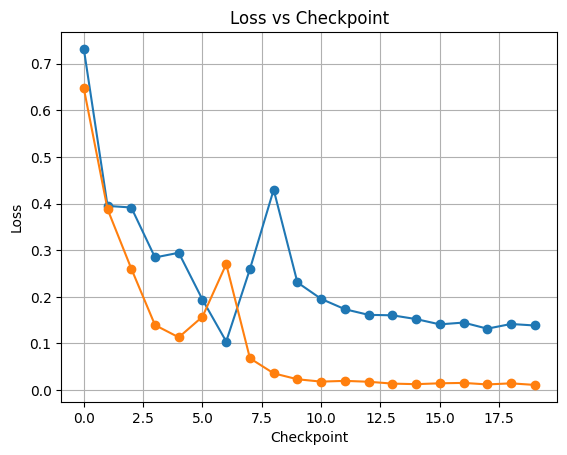

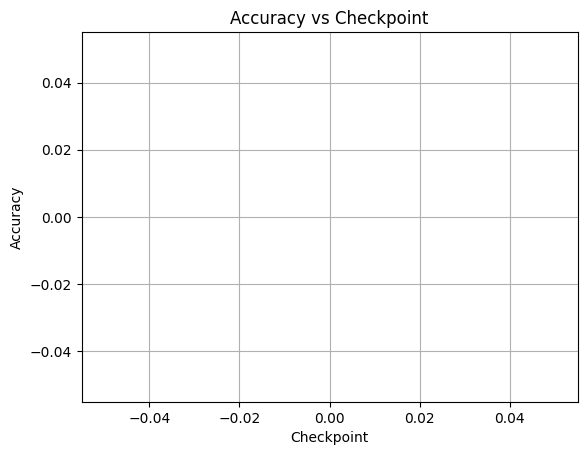

In [ ]:
import torch
import os
# Path to the directory containing the files
directory = f"./data_runs/{name_of_experiment}/checkpoints"
#directory = f"./data_runs/experiment_moons_08/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
lossesA = []
lossesB = []
accuraciesA = []
accuraciesB = []

# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path)
        
        # Extract the loss value (assuming it is stored with the key 'loss')
        if 'loss_A' in checkpoint:
            loss = checkpoint['loss_A']
            lossesA.append((filename, loss))
        else:
            print(f"LossA not found in {filename}")
        if 'loss_B' in checkpoint:
            loss = checkpoint['loss_B']
            lossesB.append((filename, loss))
        else:
            print(f"LossB not found in {filename}")

        if 'accuracy_A' in checkpoint:
            accuracy = checkpoint['accuracy_A']
            accuraciesA.append((filename, accuracy))
        else:
            print(f"Accuracy A not found in {filename}")

        if 'accuracy_B' in checkpoint:
            accuracy = checkpoint['accuracy_B']
            accuraciesB.append((filename, accuracy))
        else:
            print(f"Accuracy B not found in {filename}")

# Print the extracted losses
for filename, loss in lossesA:
    print(f"{filename}: LossA = {loss}")
for filename, loss in lossesB:
    print(f"{filename}: LossB = {loss}")

# Print the extracted losses
for filename, accuracy in accuraciesA:
    print(f"{filename}: Accuracy = {accuracy}")
for filename, accuracy in accuraciesB:
    print(f"{filename}: Accuracy = {accuracy}")

# Optional: Plot the losses for visualization
import matplotlib.pyplot as plt

# Extracting just the loss values for plotting
loss_values = [loss for _, loss in lossesA]
plt.plot(loss_values, marker='o', label='model A')
loss_values = [loss for _, loss in lossesB]
plt.plot(loss_values, marker='o', label='model B')
plt.title("Loss vs Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Extracting just the loss values for plotting
accuracy_values = [accuracy for _, accuracy in accuraciesA]
plt.plot(accuracy_values, marker='o', label='model A')
accuracy_values = [accuracy for _, accuracy in accuraciesB]
plt.plot(accuracy_values, marker='o', label='model B')
plt.title("Accuracy vs Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [ ]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed


In [ ]:
import torch

# Load the .pth file
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint10.pth', map_location=torch.device('cpu'))
print(type(checkpoint))
checkpoint['model_state_dict']


<class 'dict'>


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10156\2629051906.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'./data_runs/{name_of_experimen

OrderedDict([('alpha',
              tensor([-0.0125, -0.0176, -0.0232, -0.0183, -0.0027, -0.0443, -0.0145, -0.2646,
                      -0.0248, -0.5596,  0.1471, -0.1097, -0.1492, -0.1778,  0.0481,  0.0646,
                       0.2945,  0.0266,  0.3211,  0.1230, -1.1382, -0.1040,  0.2167,  0.2027,
                       0.2118, -0.0827,  0.0591,  0.0096,  0.0081])),
             ('bias', tensor([-0.0108])),
             ('phases',
              tensor([-0.1714,  0.0290, -0.0602,  0.3793, -0.0110,  0.0763,  0.0540, -0.0922,
                      -0.6505,  0.1497,  0.5390,  3.1698, -1.0237, -0.3132,  0.2370])),
             ('fc.weight',
              tensor([[ 2.6431, -0.6957],
                      [ 2.9011, -0.4326],
                      [ 2.1585, -0.7287],
                      [ 1.7431,  0.8088],
                      [ 2.4911, -1.3772],
                      [-2.8624,  0.3889],
                      [ 2.2417,  0.9271],
                      [ 2.9565, -1.5018],
              